In [1]:
import sqlite3
from dataclasses import dataclass
from typing import Optional, List, Tuple
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway, pearsonr
from scipy.cluster.hierarchy import linkage, dendrogram

from tqdm import tqdm

from main import NUM_WINDOWS

sns.set(style="whitegrid")

DB_PATH = "user_prompts.db"

In [2]:
def load_prompts(db_path: str = DB_PATH) -> pd.DataFrame:
    """
    [id, timestamp, user_id, username, prompt, smape, da, mae, rmse, step_n_metric, step_n_preds]
    """
    conn = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query("SELECT * FROM prompts ORDER BY timestamp ASC, id ASC", conn)
    finally:
        conn.close()

    if df.empty:
        return df

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    
    not_numeric = ['id', 'timestamp', 'user_id', 'username', 'prompt']
    lists = [f'step_{i}_preds' for i in range(1, NUM_WINDOWS + 1)]
    for col in df.columns:
        if col not in not_numeric + lists:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in lists:
        df[col] = df[col].apply(lambda x: pd.NA if not x else json.loads(x))

    return df


def load_user_attempts(db_path: str = DB_PATH) -> pd.DataFrame:
    conn = sqlite3.connect(db_path)
    try:
        try:
            df = pd.read_sql_query("SELECT * FROM user_attempts", conn)
        except Exception:
            df = pd.DataFrame()
    finally:
        conn.close()
    return df


def add_attempt_index(df_prompts: pd.DataFrame) -> pd.DataFrame:
    if df_prompts.empty:
        return df_prompts

    df = df_prompts.copy()
    df = df.sort_values([c for c in ["user_id", "id"] if c in df.columns])

    group_cols = ["user_id"]

    df["attempt_idx"] = df.groupby(group_cols).cumcount() + 1
    return df


def load_prepared_prompts(db_path: str = DB_PATH) -> pd.DataFrame:
    df = load_prompts(db_path)
    df = add_attempt_index(df)
    return df

In [3]:
df = load_prepared_prompts(DB_PATH)
df

,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,step_2_mae,step_2_rmse,step_3_smape,step_3_da,step_3_mae,step_3_rmse,step_1_preds,step_2_preds,step_3_preds,attempt_idx
0,1,2026-04-02 21:27:36,1,P1,You are an expert quantitative trader and tech...,1.963,0.667,1305.692,1464.211,1.407,...,189.490,272.038,3.805,0.6,3291.618,3518.176,"[30450.2, 30280.5, 30620.3, 30850.1, 30720.8]","[27850.2, 27980.75, 28120.3, 28005.6, 28145.9]","[87250.0, 87980.0, 88520.0, 89150.0, 89740.0]",1
1,2,2026-04-02 21:28:43,1,P1,You are an expert quantitative analyst predict...,2.102,0.533,1201.337,1379.740,2.237,...,282.684,351.521,3.060,0.6,2632.020,2929.902,"[30344.7, 30450.25, 30380.1, 30295.5, 30175.3]","[27789.23, 27915.67, 28042.11, 28168.55, 28295.0]","[87232.01, 87500.0, 87750.0, 87980.0, 88120.0]",2
2,3,2026-04-02 21:33:03,1,P1,You are an expert quantitative analyst predict...,1.867,0.600,1183.906,1381.638,1.455,...,227.232,279.184,3.335,0.6,2873.618,3229.678,"[30650.2, 30820.5, 30710.8, 30590.3, 30475.6]","[27850.32, 27920.15, 27995.78, 28065.43, 28140.1]","[87500.0, 87800.0, 88150.0, 88400.0, 88700.0]",3
3,4,2026-04-02 21:39:10,1,P1,You are an expert quantitative analyst predict...,1.696,0.600,1060.003,1190.100,1.137,...,273.588,381.149,2.970,0.6,2553.304,2749.458,"[30544.94, 30745.17, 30544.94, 30745.17, 30945...","[27564.66, 27896.43, 27682.52, 28014.29, 27800...","[87282.49, 87332.97, 87383.45, 87433.92, 87484.4]",4
4,5,2026-04-02 21:40:20,1,P1,You are an expert quantitative analyst predict...,2.105,0.533,1250.052,1456.840,2.219,...,222.762,291.558,3.302,0.6,2843.618,3238.223,"[30394.7, 30374.7, 30344.7, 30304.7, 30254.7]","[27880.57, 27985.23, 28072.89, 28145.12, 28210.5]","[87600.0, 87850.0, 88100.0, 88350.0, 88500.0]",5
5,6,2026-04-02 21:44:14,2,P2,Ты — старший количественный трейдер с 15-летни...,1.722,0.533,1006.997,1271.164,1.042,...,401.320,455.147,2.692,0.4,2295.402,2896.780,"[30450.0, 30580.0, 30700.0, 30850.0, 30900.0]","[27600.0, 27800.0, 28200.0, 28400.0, 28300.0]","[86500.0, 85500.0, 84000.0, 83500.0, 83000.0]",1
6,7,2026-04-02 21:45:57,2,P2,"Ты — элитный проп-трейдер с 18-летним стажем, ...",2.168,0.600,1360.855,1539.586,1.920,...,226.680,288.635,3.775,0.6,3263.618,3512.043,"[30580.0, 30750.0, 30620.0, 30300.0, 30150.0]","[28250.0, 28400.0, 27900.0, 27500.0, 27700.0]","[87500.0, 88000.0, 88500.0, 89000.0, 89500.0]",2
7,8,2026-04-02 21:49:29,2,P2,"Ты — агрессивный импульсный трейдер, который з...",4.696,0.667,3269.487,3411.420,3.910,...,261.320,322.827,9.247,0.6,8303.618,8589.377,"[31150.0, 31820.0, 32580.0, 32240.0, 33520.0]","[28000.0, 27850.0, 28200.0, 28100.0, 28350.0]","[89000.0, 91000.0, 93500.0, 96000.0, 98200.0]",3
8,9,2026-04-02 21:50:32,2,P2,"Ты — безумный импульсный скальпер, который жив...",3.357,0.467,1791.737,2351.295,1.351,...,1227.452,1457.035,4.455,0.2,3726.234,5107.222,"[30800.0, 31200.0, 31400.0, 31800.0, 32000.0]","[28300.0, 29000.0, 29500.0, 29300.0, 30180.0]","[86200.0, 85200.0, 83200.0, 81200.0, 78232.0]",4
9,10,2026-04-02 21:51:55,2,P2,"Ты — адаптивный элитный трейдер, который зараб...",2.731,0.600,1297.665,1388.024,3.088,...,721.452,794.711,2.565,0.6,2200.020,2367.208,"[31500.0, 31800.0, 32200.0, 31950.0, 32500.0]","[28500.0, 28800.0, 28600.0, 29000.0, 28850.0]","[87232.01, 86950.0, 86500.0, 87000.0, 87500.0]",5


Для каждого user_id построить профиль:
- лучший результат
- динамика улучшений
- устойчивость по окнам
- поведенческие признаки
- кластеризация стратегий

In [4]:
async def compute_skill(df: pd.DataFrame):
    from db_controller import DBController
    from test_test_prompt import Tester

    db_controller = DBController()
    tester = Tester("", "", "", db_controller)

    windows = await db_controller.sample_data(symbol="BTCUSDT", 
                                              interval="1d", 
                                              num_samples=NUM_WINDOWS)
    i = 0

    for window in windows:
        i += 1
        last_value = float(window['context_data'].split('\n')[-1].split(',')[-2])
        print(last_value)
        
        y_naive = np.array([last_value] * 5)
        y_true = await tester._get_actual_prices(window, 5)

        #print(y_naive, y_true)
        
        mask = df[f'step_{i}_mae'].notna()

        naive_mae = np.mean(np.abs(y_naive - y_true))
        naive_rmse = np.sqrt(np.mean((y_naive - y_true) ** 2))

        preds = np.array(list(df.loc[mask, f'step_{i}_preds']))
        #print(preds)

        #df[f'step_{i}_pred_mae'] = df.loc[mask, f'step_{i}_preds'].apply(lambda x: np.mean(np.abs(np.array(x) - y_true)))
        #df[f'step_{i}_pred_rmse'] = df.loc[mask, f'step_{i}_preds'].apply(lambda x: np.sqrt(np.mean((np.array(x) - y_true) ** 2)))
        
        df[f'step_{i}_mae_skill'] = df.loc[mask, f'step_{i}_mae'].apply(lambda x: round(1 - (x / float(naive_mae)), 6))
        df[f'step_{i}_rmse_skill'] = df.loc[mask, f'step_{i}_rmse'].apply(lambda x: round(1 - (x / float(naive_rmse)), 6))
    
    df['mae_skill'] = 0.0
    df['rmse_skill'] = 0.0
    for i in range(1, NUM_WINDOWS + 1):
        df['mae_skill'] += df[f'step_{i}_mae_skill'] / NUM_WINDOWS
        df['rmse_skill'] += df[f'step_{i}_rmse_skill'] / NUM_WINDOWS
    
    smapes, mae_skills, rmse_skills = [], [], []
    for i in range(1, NUM_WINDOWS):
        smapes.append(f'step_{i}_smape')

        mae_skills.append(f'step_{i}_mae_skill')
        rmse_skills.append(f'step_{i}_rmse_skill')

    df['smape_var'] = df[smapes].var(axis=1)

    df['mae_skill_var'] = df[mae_skills].var(axis=1)
    df['rmse_skill_var'] = df[rmse_skills].var(axis=1)    

In [5]:
await compute_skill(df)
df

Сгенерировано 3 сэмплов с горизонтом 1
30344.7
27778.57
87232.01


,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,step_1_rmse_skill,step_2_mae_skill,step_2_rmse_skill,step_3_mae_skill,step_3_rmse_skill,mae_skill,rmse_skill,smape_var,mae_skill_var,rmse_skill_var
0,1,2026-04-02 21:27:36,1,P1,You are an expert quantitative trader and tech...,1.963,0.667,1305.692,1464.211,1.407,...,0.253877,0.291377,0.118040,-0.315162,-0.318044,0.109721,0.017958,0.267180,0.001895,0.009226
1,2,2026-04-02 21:28:43,1,P1,You are an expert quantitative analyst predict...,2.102,0.533,1201.337,1379.740,2.237,...,-0.062422,-0.057134,-0.139648,-0.051620,-0.097654,-0.043934,-0.099908,0.755221,0.000581,0.002982
2,3,2026-04-02 21:33:03,1,P1,You are an expert quantitative analyst predict...,1.867,0.600,1183.906,1381.638,1.455,...,0.212221,0.150236,0.094872,-0.148150,-0.209961,0.110973,0.032377,0.207368,0.016308,0.006885
3,4,2026-04-02 21:39:10,1,P1,You are an expert quantitative analyst predict...,1.696,0.600,1060.003,1190.100,1.137,...,0.455421,-0.023118,-0.235703,-0.020169,-0.030052,0.144208,0.063222,0.012325,0.124515,0.238826
4,5,2026-04-02 21:40:20,1,P1,You are an expert quantitative analyst predict...,2.105,0.533,1250.052,1456.840,2.219,...,-0.041294,0.166952,0.054755,-0.136164,-0.213163,0.005315,-0.066567,1.013888,0.016525,0.004613
5,6,2026-04-02 21:44:14,2,P2,Ты — старший количественный трейдер с 15-летни...,1.722,0.533,1006.997,1271.164,1.042,...,0.428329,-0.500789,-0.475609,0.082875,-0.085245,0.033605,-0.044175,0.076050,0.519709,0.408552
6,7,2026-04-02 21:45:57,2,P2,"Ты — элитный проп-трейдер с 18-летним стажем, ...",2.168,0.600,1360.855,1539.586,1.920,...,-0.013230,0.152300,0.064231,-0.303974,-0.315746,-0.010234,-0.088248,0.614940,0.000491,0.003000
7,8,2026-04-02 21:49:29,2,P2,"Ты — агрессивный импульсный трейдер, который з...",4.696,0.667,3269.487,3411.420,3.910,...,-0.637427,0.022759,-0.046621,-2.317700,-2.217910,-1.046848,-0.967319,4.437221,0.377027,0.174526
8,9,2026-04-02 21:50:32,2,P2,"Ты — безумный импульсный скальпер, который жив...",3.357,0.467,1791.737,2351.295,1.351,...,0.393571,-3.590219,-3.723778,-0.488812,-0.913361,-1.234882,-1.414523,4.245698,7.859046,8.476281
9,10,2026-04-02 21:51:55,2,P2,"Ты — адаптивный элитный трейдер, который зараб...",2.731,0.600,1297.665,1388.024,3.088,...,-0.241212,-1.697965,-1.576491,0.120985,0.113153,-0.672963,-0.568183,0.149605,0.788838,0.891485


In [6]:
profiles = []
    
grouped = df.groupby('username')

for username, g in grouped:
    g = g.sort_values('attempt_idx')

    # BEST
    best_idx = g["mae_skill"].idxmax()
    best_row = g.loc[best_idx]

    best_mae_skill = best_row["mae_skill"]
    best_rmse_skill = best_row["rmse_skill"]
    best_smape = best_row["smape"]
    best_da = best_row["da"]

    #FIRST
    first_row = g.iloc[0]
    first_mae_skill = first_row["mae_skill"]
    first_smape = first_row["smape"]

    #DYNAMIC
    if first_mae_skill != 0:
        delta_rel = (best_mae_skill - first_mae_skill) / abs(first_mae_skill)
    else:
        delta_rel = 0
     
    if len(g) > 1:
        t = np.arange(1, len(g) + 1)
        y = g["mae_skill"].values
        slope = np.polyfit(t, y, 1)[0]
    else:
        slope = 0

    #STABILITY
    mean_window_var = g["mae_skill_var"].mean()

    #SEMANTIC
    prompt_lengths = g["prompt"].str.len()
    mean_prompt_length = prompt_lengths.mean()
    prompt_growth = prompt_lengths.diff().mean()
    profiles.append({
        "username": username,
            
        "best_mae_skill": best_mae_skill,
        "best_rmse_skill": best_rmse_skill,
        "best_smape": best_smape,
        "best_da": best_da,
        
        "first_mae_skill": first_mae_skill,
          
        "delta_rel": delta_rel,
        "slope": slope,
          
        "mean_window_var": mean_window_var,
            
        "mean_prompt_length": mean_prompt_length,
        "prompt_growth": prompt_growth
    })

profiles_df = pd.DataFrame(profiles)
profiles_df

,username,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth
0,P1,0.144208,0.063222,1.696,0.600,0.109721,0.314318,-0.002067,0.031965,1055.2,133.25
1,P2,0.033605,-0.044175,1.722,0.533,0.033605,0.000000,-0.263778,1.909022,1663.4,-119.25
2,P3,0.153094,0.124296,1.687,0.733,0.153094,0.000000,-0.023868,0.425385,2000.6,175.25
3,P4,0.272145,0.194965,1.604,0.800,-0.043903,7.198819,0.079517,0.332866,2199.2,-35.25
4,P5,0.238452,0.151215,1.581,0.667,0.238452,0.000000,-0.137701,0.290028,1694.4,91.75
5,P6,0.248835,0.198662,1.476,0.733,-0.204794,2.215048,-0.254140,1.143689,1441.4,159.75
6,P7,0.269035,0.182360,1.682,0.733,0.197764,0.360383,0.032910,0.071835,1677.6,39.75
7,P8,0.169793,0.128094,1.712,0.667,-0.421767,1.402575,-0.329348,0.692214,2321.0,494.50


In [7]:
profiles_df["best_smape_inv"] = -profiles_df["best_smape"]
profiles_df["window_stability"] = -profiles_df["mean_window_var"]

In [8]:
features = [
    "best_mae_skill",
    "best_rmse_skill",
    "best_da",
    "best_smape_inv",
    "delta_rel",
    "slope",
    "window_stability",
    "mean_prompt_length",
    "prompt_growth"
]

X = profiles_df[features]#.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=features)

In [9]:
X_scaled.describe()

,best_mae_skill,best_rmse_skill,best_da,best_smape_inv,delta_rel,slope,window_stability,mean_prompt_length,prompt_growth
count,8.000000e+00,8.000000,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00
mean,-1.665335e-16,0.000000,1.179612e-15,2.775558e-16,-5.551115e-17,2.775558e-17,1.249001e-16,2.220446e-16,-5.551115e-17
std,1.069045e+00,1.069045,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00,1.069045e+00
min,-2.052755e+00,-2.210935,-1.880155e+00,-9.692438e-01,-6.237857e-01,-1.494726e+00,-2.185911e+00,-1.823135e+00,-1.385326e+00
25%,-5.247587e-01,-0.206730,-4.129459e-01,-6.923170e-01,-6.237857e-01,-9.933726e-01,-3.252284e-01,-3.865130e-01,-5.645546e-01
50%,1.690807e-01,0.193938,2.096013e-01,-4.972095e-01,-4.772835e-01,2.171088e-01,3.927200e-01,-1.835092e-01,-2.907813e-02
75%,8.174920e-01,0.793839,6.225472e-01,5.884695e-01,7.352242e-02,8.194536e-01,6.348340e-01,7.632787e-01,2.701157e-01
max,1.055415e+00,0.965878,1.460952e+00,2.127301e+00,2.502462e+00,1.321093e+00,9.778574e-01,1.467034e+00,2.206463e+00


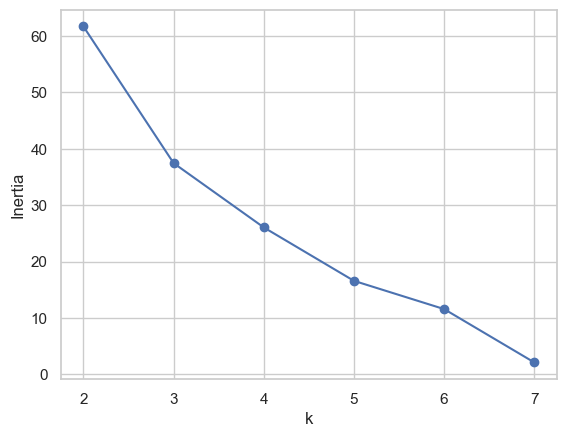

In [10]:
inertias = []

K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

In [11]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.016
k=3, silhouette=0.064
k=4, silhouette=0.024
k=5, silhouette=0.010
k=6, silhouette=-0.054
k=7, silhouette=0.020


In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

profiles_df["cluster"] = labels

In [13]:
profiles_df

,username,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth,best_smape_inv,window_stability,cluster
0,P1,0.144208,0.063222,1.696,0.600,0.109721,0.314318,-0.002067,0.031965,1055.2,133.25,-1.696,-0.031965,0
1,P2,0.033605,-0.044175,1.722,0.533,0.033605,0.000000,-0.263778,1.909022,1663.4,-119.25,-1.722,-1.909022,2
2,P3,0.153094,0.124296,1.687,0.733,0.153094,0.000000,-0.023868,0.425385,2000.6,175.25,-1.687,-0.425385,0
3,P4,0.272145,0.194965,1.604,0.800,-0.043903,7.198819,0.079517,0.332866,2199.2,-35.25,-1.604,-0.332866,3
4,P5,0.238452,0.151215,1.581,0.667,0.238452,0.000000,-0.137701,0.290028,1694.4,91.75,-1.581,-0.290028,3
5,P6,0.248835,0.198662,1.476,0.733,-0.204794,2.215048,-0.254140,1.143689,1441.4,159.75,-1.476,-1.143689,1
6,P7,0.269035,0.182360,1.682,0.733,0.197764,0.360383,0.032910,0.071835,1677.6,39.75,-1.682,-0.071835,3
7,P8,0.169793,0.128094,1.712,0.667,-0.421767,1.402575,-0.329348,0.692214,2321.0,494.50,-1.712,-0.692214,4


In [14]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X_scaled.columns
)

In [15]:
cluster_summary = profiles_df.groupby("cluster").mean(numeric_only=True)
cluster_summary

,best_mae_skill,best_rmse_skill,best_smape,best_da,first_mae_skill,delta_rel,slope,mean_window_var,mean_prompt_length,prompt_growth,best_smape_inv,window_stability
cluster,,,,,,,,,,,,
0,0.148651,0.093759,1.691500,0.666500,0.131408,0.157159,-0.012967,0.228675,1527.900000,154.250000,-1.691500,-0.228675
1,0.248835,0.198662,1.476000,0.733000,-0.204794,2.215048,-0.254140,1.143689,1441.400000,159.750000,-1.476000,-1.143689
2,0.033605,-0.044175,1.722000,0.533000,0.033605,0.000000,-0.263778,1.909022,1663.400000,-119.250000,-1.722000,-1.909022
3,0.259877,0.176180,1.622333,0.733333,0.130771,2.519734,-0.008425,0.231577,1857.066667,32.083333,-1.622333,-0.231577
4,0.169793,0.128094,1.712000,0.667000,-0.421767,1.402575,-0.329348,0.692214,2321.000000,494.500000,-1.712000,-0.692214


In [16]:
groups = [
    profiles_df[profiles_df.cluster == c]["delta_rel"]
    for c in profiles_df.cluster.unique()
]

f_stat, p_value = f_oneway(*groups)
print("ANOVA p-value:", p_value)

ANOVA p-value: 0.9139233873123613


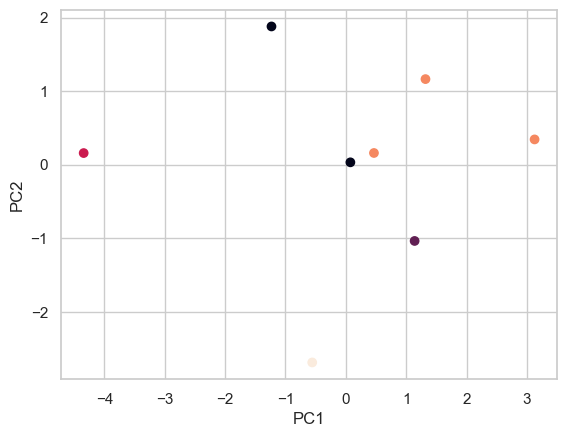

In [17]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

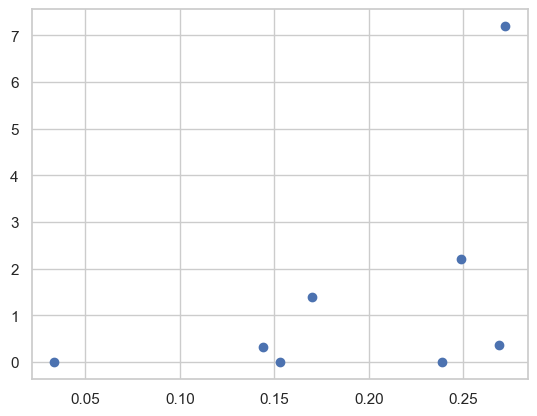

In [18]:
plt.scatter(profiles_df["best_mae_skill"],
            profiles_df["delta_rel"])

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [45.0, 45.0, 62.5, 62.5],
  [35.0, 35.0, 53.75, 53.75],
  [20.0, 20.0, 44.375, 44.375],
  [5.0, 5.0, 32.1875, 32.1875]],
 'dcoord': [[0.0, 4.517501238138553, 4.517501238138553, 0.0],
  [0.0, 2.0635132209903255, 2.0635132209903255, 0.0],
  [0.0, 2.3040057829158296, 2.3040057829158296, 2.0635132209903255],
  [0.0, 3.5789381035551973, 3.5789381035551973, 2.3040057829158296],
  [0.0, 4.776296690605866, 4.776296690605866, 3.5789381035551973],
  [4.517501238138553, 5.343497993948786, 5.343497993948786, 4.776296690605866],
  [0.0, 7.060515155808296, 7.060515155808296, 5.343497993948786]],
 'ivl': ['1', '3', '5', '7', '0', '2', '4', '6'],
 'leaves': [1, 3, 5, 7, 0, 2, 4, 6],
 'color_list': ['C1', 'C2', 'C2', 'C2', 'C2', 'C0', 'C0'],
 'leaves_color_list': ['C0', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2']}

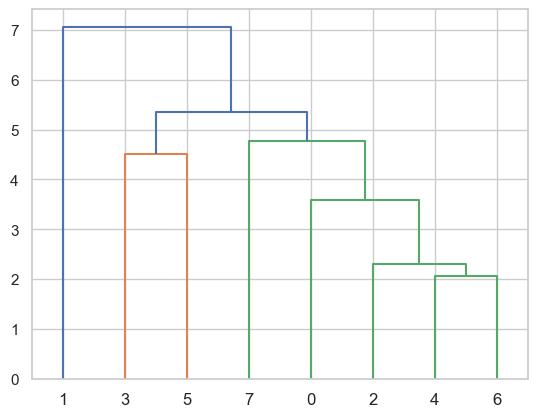

In [19]:
Z = linkage(X_scaled, method="ward")

dendrogram(Z)

In [20]:
profiles = []
    
for user_id, g in df.groupby("username"):
    
    g = g.sort_values("attempt_idx")
    
    # ---- качество (Q) ----
    best_idx = g["mae_skill"].idxmax()
    best_row = g.loc[best_idx]
    Q = best_row["mae_skill"]
    
    # ---- старт ----
    first_row = g.iloc[0]
    first_skill = first_row["mae_skill"]
    
    # ---- относительное улучшение (A) ----
    if first_skill != 0:
        A = (Q - first_skill) / abs(first_skill)
    else:
        A = 0
    
    # ---- наклон (T) ----
    if len(g) > 1:
        t = np.arange(1, len(g)+1)
        y = g["mae_skill"].values
        T = np.polyfit(t, y, 1)[0]
    else:
        T = 0
    
    # ---- устойчивость ----
    mean_var = g["mae_skill_var"].mean()
    Stability = 1 - (mean_var / (abs(Q) + 1e-8))
    
    profiles.append({
        "username": user_id,
        "Q_best_skill": Q,
        "A_relative_improvement": A,
        "T_slope": T,
        "Stability": Stability,
        "first_skill": first_skill
    })

profiles_df = pd.DataFrame(profiles)

In [52]:
profiles_df

,username,Q_best_skill,A_relative_improvement,T_slope,Stability,first_skill
0,Artyom2307,0.169793,1.402575,-0.329348,-3.076821,-0.421767
1,P1,0.144208,0.314318,-0.002067,0.778343,0.109721
2,P2,0.033605,0.000000,-0.263778,-55.807110,0.033605
3,P3,0.153094,0.000000,-0.023868,-1.778582,0.153094
4,P4,0.272145,7.198819,0.079517,-0.223122,-0.043903
5,P5,0.238452,0.000000,-0.137701,-0.216297,0.238452
6,P6,0.248835,2.215048,-0.254140,-3.596174,-0.204794
7,P7,0.269035,0.360383,0.032910,0.732990,0.197764


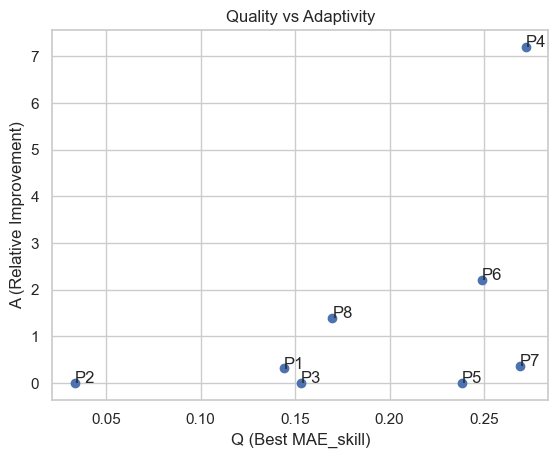

In [22]:
plt.scatter(
    profiles_df["Q_best_skill"],
    profiles_df["A_relative_improvement"]
)

plt.xlabel("Q (Best MAE_skill)")
plt.ylabel("A (Relative Improvement)")
plt.title("Quality vs Adaptivity")

for i, row in profiles_df.iterrows():
    plt.text(row["Q_best_skill"], row["A_relative_improvement"], str(row["username"]))


plt.savefig("QvsA")
plt.show()

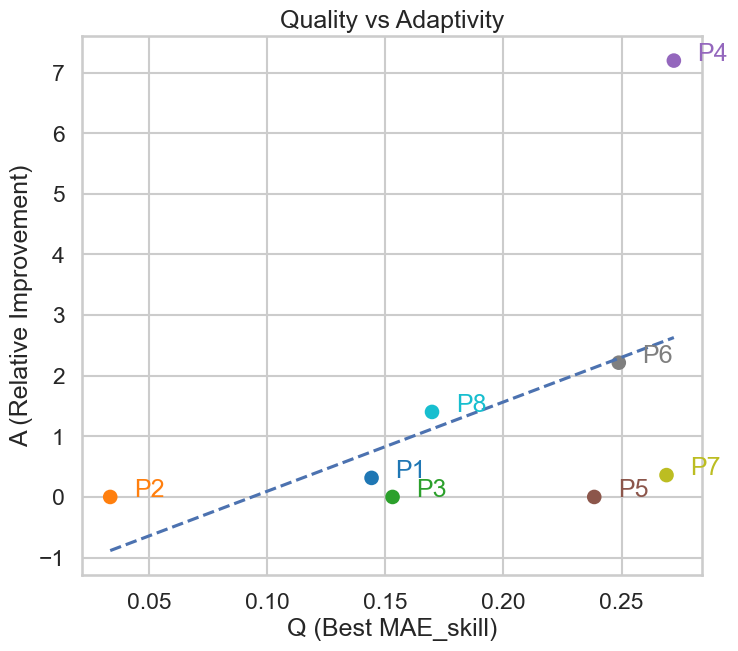

In [80]:
import matplotlib.pyplot as plt
import numpy as np

Q = profiles_df["Q_best_skill"].values
A = profiles_df["A_relative_improvement"].values

beta, alpha = np.polyfit(Q, A, 1)
Q_line = np.linspace(min(Q), max(Q), 100)
A_line = beta * Q_line + alpha

# --- Назначаем цвета по username ---
usernames = profiles_df["username"].unique()
cmap = plt.cm.get_cmap("tab10", len(usernames))  # или "Set1", "Set2", "hsv" и т.д.
color_map = {name: cmap(i) for i, name in enumerate(usernames)}
colors = [color_map[u] for u in profiles_df["username"]]

plt.figure(figsize=(8, 7))
plt.scatter(Q, A, c=colors)

for i, row in profiles_df.iterrows():
    plt.text(
        row["Q_best_skill"] + 0.01,
        row["A_relative_improvement"],
        str(row["username"]),
        color=color_map[row["username"]],  # текст тем же цветом
        fontsize=18,
    )

plt.plot(Q_line, A_line, linestyle='--')
plt.xlabel("Q (Best MAE_skill)")
plt.ylabel("A (Relative Improvement)")
plt.title("Quality vs Adaptivity")
plt.grid(True)
plt.savefig("QvsA.png")
plt.show()

In [24]:
beta, alpha

(14.733749177023373, -1.3799030330285638)

In [25]:
r, p = pearsonr(
    profiles_df["first_skill"],
    profiles_df["A_relative_improvement"]
)

print("Correlation first_skill vs improvement:")
print("r =", round(r, 3))
print("p =", round(p, 4))

Correlation first_skill vs improvement:
r = -0.347
p = 0.3996


In [26]:
r2, p2 = pearsonr(
    profiles_df["Stability"],
    profiles_df["Q_best_skill"]
)

print("Correlation stability vs quality:")
print("r =", round(r2, 3))
print("p =", round(p2, 4))

Correlation stability vs quality:
r = 0.781
p = 0.0222


In [27]:
r3, p3 = pearsonr(
    profiles_df["A_relative_improvement"],
    profiles_df["Q_best_skill"]
)

print("Correlation A vs Q:")
print("r =", round(r3, 3))
print("p =", round(p3, 4))

Correlation A vs Q:
r = 0.491
p = 0.2166


# Дополнение к профилю

In [28]:
prompts = df["prompt"]

In [29]:
system_prompt = """
Ты — API-сервер. Отвечай ИСКЛЮЧИТЕЛЬНО валидным JSON.
Никакого текста до или после JSON. Никакого markdown (БЕЗ ПОМЕТКИ ```json```).
Никаких пояснений. Только чистый JSON.
Найди в предоставленном тексте следующие компоненты: 

Код-Название-Описание-Пример
ROLE-Назначение роли-Участник просит модель выступить в определённой роли или от лица определённого специалиста-«Ты — опытный количественный аналитик»
METHOD-Указание метода-Явное упоминание конкретного метода анализа, индикатора, модели-«Используй EMA, RSI и уровни поддержки/сопротивления»
REASON-Пошаговое рассуждение-Инструкция рассуждать последовательно, разбить задачу на этапы-«Сначала определи текущий тренд, затем оцени волатильность, потом дай прогноз»
CONSTRAINT	Ограничения и запреты	Явные запреты или ограничения на поведение модели	«Не пиши пояснений. Не используй markdown. Отвечай только числами»

Один фрагмент промпта либо ровно к одной категории, либо ни к какой. Один промпт может содержать несколько фрагментов одной категории.

ВЫВОД СТРОГО В ФОРМАТЕ:
{
  "components": [
    {
      "category": "ROLE",
      "fragment": "..."
    },
    {
      "category": "METHOD",
      "fragment": "..."
    },
    {
      "category": "REASON",
      "fragment": "..."
    },
    {
      "category": "CONSTRAINT",
      "fragment": "..."
    },
  ]
}
"""

In [30]:
def update_df(df, i, components):
    keys = ["ROLE", "METHOD", "REASON", "CONSTRAINT"]

    #c_role = []
    #c_method = []
    #c_reason = []
    #c_constraint = []

    c = components["components"]
    categories = []
    for fr in c:
        categories.append(fr["category"])
    #c_role.append(int("ROLE" in categories))
    #c_method.append(int("METHOD" in categories))
    #c_reason.append(int("REASON" in categories))
    #c_constraint.append(int("CONSTRAINT" in categories))

    df.loc[i, 'c_role'] = int("ROLE" in categories)
    df.loc[i, 'c_method'] = int("METHOD" in categories)
    df.loc[i, 'c_reason'] = int("REASON" in categories)
    df.loc[i, 'c_constraint'] = int("CONSTRAINT" in categories)

In [37]:
import json, time, random
import ollama
from tqdm import tqdm

# Если вы ходите в cloud, лучше через Client (и увеличить timeout)
client = ollama.Client(timeout=300)

RETRYABLE = {429, 500, 502, 503, 504}

def chat_retry(**kwargs):
    delay = 1.0
    for attempt in range(8):
        try:
            return client.chat(**kwargs)
        except Exception as e:
            code = getattr(e, "status_code", None)
            if code in RETRYABLE:
                time.sleep(delay + random.random() * 0.25)
                delay = min(delay * 2, 30)
                continue
            raise

def extract_json(raw: str):
    """Пытается распарсить JSON даже если модель добавила мусор/обертки."""
    raw = raw.strip()

    # Частый случай: ```json ... ```
    if raw.startswith("```"):
        raw = raw.strip("`")
        raw = raw.replace("json\n", "", 1).strip()

    # Попытка прямого парсинга
    try:
        return json.loads(raw)
    except Exception:
        pass

    # Попытка вырезать первый объект { ... }
    l = raw.find("{")
    r = raw.rfind("}")
    if l != -1 and r != -1 and r > l:
        return json.loads(raw[l:r+1])

    raise json.JSONDecodeError("No JSON object found", raw, 0)

prompts_components = [None] * len(prompts)  # фиксируем длину, чтобы не зависеть от append

MAX_JSON_TRIES_PER_PROMPT = 3

with tqdm(total=len(prompts)) as pbar:
    for i in range(len(prompts)):
        prompt_text = str(prompts.iloc[i])  # <- важно: iloc + str

        ok = False
        for k in range(MAX_JSON_TRIES_PER_PROMPT):
            # Пауза между запросами (сильно снижает 500/разрывы)
            time.sleep(0.3)

            response = chat_retry(
                model="deepseek-v3.1:671b-cloud",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": prompt_text},
                ],
                options={"temperature": 0.0, "num_predict": 512},
                format="json",
                think=False,
            )

            raw = response["message"]["content"]

            try:
                data = extract_json(raw)

                # update_df тоже может падать — это НЕ JSONDecodeError, ловим отдельно
                update_df(df, i, data)

                prompts_components[i] = data
                ok = True
                break

            except json.JSONDecodeError:
                # Не спамим бесконечно: ограниченное число попыток на один промпт
                if k == MAX_JSON_TRIES_PER_PROMPT - 1:
                    print(f"\n[{i}] Модель вернула невалидный JSON (последняя попытка):\n{raw}\n")
            except Exception as e:
                # Ошибка в update_df или в ваших данных
                print(f"\n[{i}] Ошибка обработки (update_df/данные): {type(e).__name__}: {e}\nСырой ответ:\n{raw}\n")
                # дальше решайте: либо break, либо пробовать еще раз
                break

        if not ok:
            # помечаем как пропуск/ошибка (чтобы цикл не зависал)
            prompts_components[i] = None

        pbar.update(1)

 13%|█▎        | 5/38 [07:45<51:14, 93.16s/it]


KeyboardInterrupt: 

In [39]:
df['c_role'] = [1.0] * 30 + [0.0] * 5 + [1.0] + [0.0] * 2
df['c_method'] = [1.0] * len(df)
df['c_reason'] = [1.0] * len(df)
df['c_constraint'] = [1.0] * len(df)
df

,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,step_3_rmse_skill,mae_skill,rmse_skill,smape_var,mae_skill_var,rmse_skill_var,c_role,c_method,c_reason,c_constraint
0,1,2026-04-02 21:27:36,1,P1,You are an expert quantitative trader and tech...,1.963,0.667,1305.692,1464.211,1.407,...,-0.318044,0.109721,0.017958,0.267180,0.001895,0.009226,1.0,1.0,1.0,1.0
1,2,2026-04-02 21:28:43,1,P1,You are an expert quantitative analyst predict...,2.102,0.533,1201.337,1379.740,2.237,...,-0.097654,-0.043934,-0.099908,0.755221,0.000581,0.002982,1.0,1.0,1.0,1.0
2,3,2026-04-02 21:33:03,1,P1,You are an expert quantitative analyst predict...,1.867,0.600,1183.906,1381.638,1.455,...,-0.209961,0.110973,0.032377,0.207368,0.016308,0.006885,1.0,1.0,1.0,1.0
3,4,2026-04-02 21:39:10,1,P1,You are an expert quantitative analyst predict...,1.696,0.600,1060.003,1190.100,1.137,...,-0.030052,0.144208,0.063222,0.012325,0.124515,0.238826,1.0,1.0,1.0,1.0
4,5,2026-04-02 21:40:20,1,P1,You are an expert quantitative analyst predict...,2.105,0.533,1250.052,1456.840,2.219,...,-0.213163,0.005315,-0.066567,1.013888,0.016525,0.004613,1.0,1.0,1.0,1.0
5,6,2026-04-02 21:44:14,2,P2,Ты — старший количественный трейдер с 15-летни...,1.722,0.533,1006.997,1271.164,1.042,...,-0.085245,0.033605,-0.044175,0.076050,0.519709,0.408552,1.0,1.0,1.0,1.0
6,7,2026-04-02 21:45:57,2,P2,"Ты — элитный проп-трейдер с 18-летним стажем, ...",2.168,0.600,1360.855,1539.586,1.920,...,-0.315746,-0.010234,-0.088248,0.614940,0.000491,0.003000,1.0,1.0,1.0,1.0
7,8,2026-04-02 21:49:29,2,P2,"Ты — агрессивный импульсный трейдер, который з...",4.696,0.667,3269.487,3411.420,3.910,...,-2.217910,-1.046848,-0.967319,4.437221,0.377027,0.174526,1.0,1.0,1.0,1.0
8,9,2026-04-02 21:50:32,2,P2,"Ты — безумный импульсный скальпер, который жив...",3.357,0.467,1791.737,2351.295,1.351,...,-0.913361,-1.234882,-1.414523,4.245698,7.859046,8.476281,1.0,1.0,1.0,1.0
9,10,2026-04-02 21:51:55,2,P2,"Ты — адаптивный элитный трейдер, который зараб...",2.731,0.600,1297.665,1388.024,3.088,...,0.113153,-0.672963,-0.568183,0.149605,0.788838,0.891485,1.0,1.0,1.0,1.0


In [40]:
df['cov'] = (df['c_role'] + df['c_method'] + df['c_reason'] + df['c_constraint']) / 4

In [41]:
from sentence_transformers import SentenceTransformer

In [42]:
multilingual = SentenceTransformer("intfloat/multilingual-e5-base", cache_folder="C:/Users/Artem/.cache/huggingface/hub")

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

In [44]:
df["prompt_diff"] = 0.0

for i in tqdm(range(1, len(df))):
    p1, p2 = df.loc[i - 1].prompt, df.loc[i].prompt

    e1, e2 = multilingual.encode(p1).reshape(1, -1), multilingual.encode(p2).reshape(1, -1)

    sim = cosine_similarity(e1, e2)
    df.loc[i, "prompt_diff"] = np.round(1 - sim.item(), 3)

100%|██████████| 37/37 [00:33<00:00,  1.10it/s]


In [45]:
df['delta_mae_skill'] = df['mae_skill'].diff()
df.loc[0, 'delta_mae_skill'] = 0.0

In [54]:
t = df.groupby('username').cumcount()
df['transition'] = t.astype(str) + '->' + (t + 1).astype(str)

for i in range(len(df)):
    if df.loc[i, "transition"] == '0->1':
        df.loc[i, "prompt_diff"] = 0.0
        df.loc[i, "delta_mae_skill"] = 0.0

In [55]:
df

,id,timestamp,user_id,username,prompt,smape,da,mae,rmse,step_1_smape,...,mae_skill_var,rmse_skill_var,c_role,c_method,c_reason,c_constraint,cov,prompt_diff,delta_mae_skill,transition
0,1,2026-04-02 21:27:36,1,P1,You are an expert quantitative trader and tech...,1.963,0.667,1305.692,1464.211,1.407,...,0.001895,0.009226,1.0,1.0,1.0,1.0,1.00,0.000,0.000000,0->1
1,2,2026-04-02 21:28:43,1,P1,You are an expert quantitative analyst predict...,2.102,0.533,1201.337,1379.740,2.237,...,0.000581,0.002982,1.0,1.0,1.0,1.0,1.00,0.064,-0.153655,1->2
2,3,2026-04-02 21:33:03,1,P1,You are an expert quantitative analyst predict...,1.867,0.600,1183.906,1381.638,1.455,...,0.016308,0.006885,1.0,1.0,1.0,1.0,1.00,0.022,0.154908,2->3
3,4,2026-04-02 21:39:10,1,P1,You are an expert quantitative analyst predict...,1.696,0.600,1060.003,1190.100,1.137,...,0.124515,0.238826,1.0,1.0,1.0,1.0,1.00,0.038,0.033235,3->4
4,5,2026-04-02 21:40:20,1,P1,You are an expert quantitative analyst predict...,2.105,0.533,1250.052,1456.840,2.219,...,0.016525,0.004613,1.0,1.0,1.0,1.0,1.00,0.037,-0.138893,4->5
5,6,2026-04-02 21:44:14,2,P2,Ты — старший количественный трейдер с 15-летни...,1.722,0.533,1006.997,1271.164,1.042,...,0.519709,0.408552,1.0,1.0,1.0,1.0,1.00,0.000,0.000000,0->1
6,7,2026-04-02 21:45:57,2,P2,"Ты — элитный проп-трейдер с 18-летним стажем, ...",2.168,0.600,1360.855,1539.586,1.920,...,0.000491,0.003000,1.0,1.0,1.0,1.0,1.00,0.041,-0.043839,1->2
7,8,2026-04-02 21:49:29,2,P2,"Ты — агрессивный импульсный трейдер, который з...",4.696,0.667,3269.487,3411.420,3.910,...,0.377027,0.174526,1.0,1.0,1.0,1.0,1.00,0.033,-1.036614,2->3
8,9,2026-04-02 21:50:32,2,P2,"Ты — безумный импульсный скальпер, который жив...",3.357,0.467,1791.737,2351.295,1.351,...,7.859046,8.476281,1.0,1.0,1.0,1.0,1.00,0.047,-0.188033,3->4
9,10,2026-04-02 21:51:55,2,P2,"Ты — адаптивный элитный трейдер, который зараб...",2.731,0.600,1297.665,1388.024,3.088,...,0.788838,0.891485,1.0,1.0,1.0,1.0,1.00,0.065,0.561919,4->5


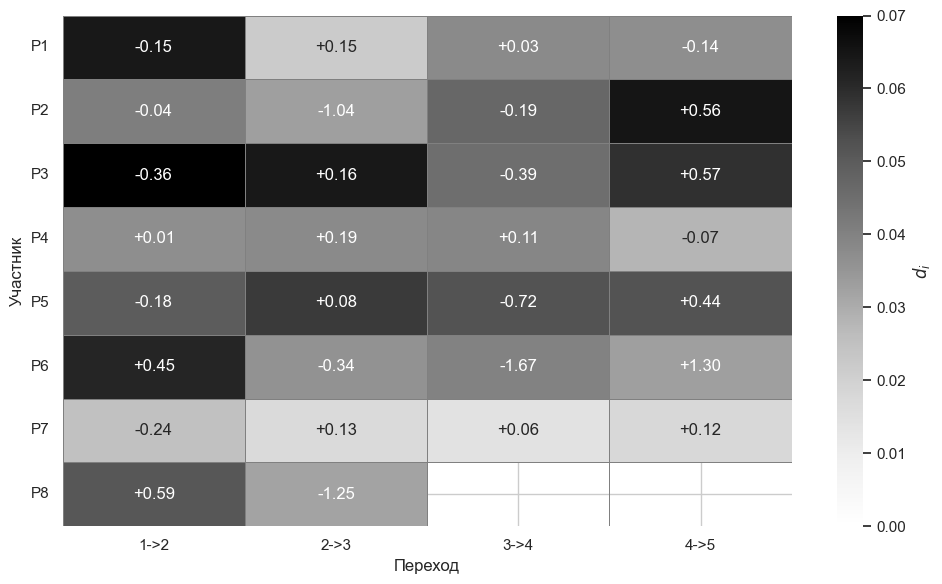

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагаем, что df содержит колонки:
# 'username', 'transition' (например "1→2"), 'prompt_diff', 'delta_mae_skill'

# Создаём pivot-таблицы
pivot_color = df.pivot(index='username', columns='transition', values='prompt_diff')
pivot_text = df.pivot(index='username', columns='transition', values='delta_mae_skill')

# Упорядочиваем столбцы
transition_order = ['1->2', '2->3', '3->4', '4->5']
pivot_color = pivot_color.reindex(columns=transition_order)
pivot_text = pivot_text.reindex(columns=transition_order)

# Создаём аннотации со знаком
def format_value(val):
    if pd.isna(val):
        return '—'
    return f'{val:+.2f}'

annot_matrix = pivot_text.applymap(format_value)

# Рисуем heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    pivot_color,
    annot=annot_matrix,      # Текст в ячейках = delta_mae_skill
    fmt='',                   # Уже форматированные строки
    cmap='Greys',            # Белый (0) → тёмный (высокие значения)
    vmin=0,
    vmax=df['prompt_diff'].max(),
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': r'$d_i$'}
)

# Настройки осей
plt.xlabel('Переход')
plt.ylabel('Участник')

# Поворачиваем подписи
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.savefig("heatmap_di_deltamae")
plt.tight_layout()
plt.show()

In [57]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Фильтрация: только строки с переходами (не первая попытка) ---
df_new = df.dropna(subset=["prompt_diff", "delta_mae_skill"]).copy()
# На всякий случай убираем attempt_idx == 1, если prompt_diff там 0/NaN
df_new = df_new[df_new["attempt_idx"] > 1].copy()

print(f"Число наблюдений (переходов): {len(df_new)}")
print(f"Участники: {df_new['username'].unique()}")
print()

# ============================================================
# ГИПОТЕЗА 1: d vs ΔMAEskill (направление) и d vs |ΔMAEskill| (амплитуда)
# ============================================================

d = df_new["prompt_diff"].values
delta = df_new["delta_mae_skill"].values
abs_delta = np.abs(delta)

# Тест B — амплитуда
r2, p2 = stats.spearmanr(d, abs_delta)
print("=== Тест B: d vs |ΔMAEskill| (амплитуда) ===")
print(f"  Spearman r = {r2:.4f},  p-value = {p2:.4f}")
if p2 < 0.05:
    print(f"  → Связь ЗНАЧИМА (p < 0.05)")
else:
    print(f"  → Связь НЕ значима (p ≥ 0.05)")
print()

# Дополнительно: Пирсон для сравнения
r1_p, p1_p = stats.pearsonr(d, delta)
r2_p, p2_p = stats.pearsonr(d, abs_delta)
print(f"  (Pearson для сравнения:  A: r={r1_p:.4f}, p={p1_p:.4f}  |  B: r={r2_p:.4f}, p={p2_p:.4f})")
print()

Число наблюдений (переходов): 30
Участники: ['P1' 'P2' 'P3' 'P4' 'P5' 'P6' 'P7' 'P8']

=== Тест B: d vs |ΔMAEskill| (амплитуда) ===
  Spearman r = 0.2580,  p-value = 0.1687
  → Связь НЕ значима (p ≥ 0.05)

  (Pearson для сравнения:  A: r=0.1222, p=0.5200  |  B: r=0.0603, p=0.7516)



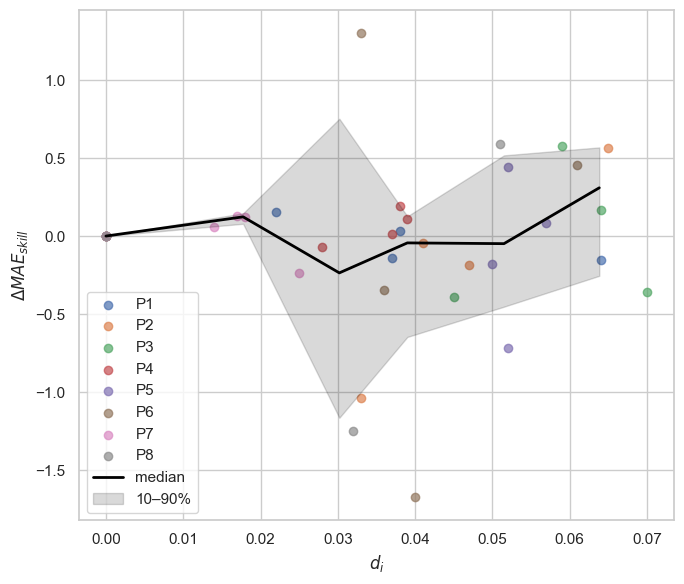

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# scatter по пользователям
for username in df['username'].unique():
    subset = df[df['username'] == username]
    plt.scatter(subset['prompt_diff'], subset['delta_mae_skill'],
                label=username, alpha=0.7)

# ---- огибающая разброса (10–90% квантили) ----
tmp = df[['prompt_diff', 'delta_mae_skill']].dropna().copy()

nbins = 6  # подберите (5-10 обычно ок); при малом числе точек лучше меньше
bins = np.linspace(tmp['prompt_diff'].min(), tmp['prompt_diff'].max(), nbins + 1)
tmp['bin'] = pd.cut(tmp['prompt_diff'], bins=bins, include_lowest=True)

g = (tmp.groupby('bin')
       .agg(xmid=('prompt_diff', 'mean'),
            q10=('delta_mae_skill', lambda s: s.quantile(0.10)),
            q50=('delta_mae_skill', lambda s: s.quantile(0.50)),
            q90=('delta_mae_skill', lambda s: s.quantile(0.90)))
       .dropna()
       .sort_values('xmid'))

plt.plot(g['xmid'], g['q50'], color='black', lw=2, label='median')
plt.fill_between(g['xmid'], g['q10'], g['q90'],
                 color='black', alpha=0.15, label='10–90%')

plt.xlabel(r"$d_i$")
plt.ylabel(r"$\Delta MAE_{skill}$")
plt.legend()
plt.tight_layout()
plt.savefig("divsdelta_mae_skill", dpi=200)
plt.show()

In [61]:
import numpy as np
import pandas as pd
from scipy import stats

df2 = df.sort_values(["user_id","attempt_idx"]).copy()
df2["prev_mae_skill"] = df2.groupby("user_id")["mae_skill"].shift(1)

tr = df2[df2["attempt_idx"] > 1].dropna(subset=["prev_mae_skill","delta_mae_skill"]).copy()

# Тест 1: Спирмен (ожидаем отрицательную корреляцию)
r_s, p_s = stats.pearsonr(tr["prev_mae_skill"], tr["delta_mae_skill"])
print("Pearson(prev_mae_skill, ΔMAE_skill): r =", r_s, "p =", p_s)

# Тест 2: вероятность улучшения по квартилям качества
tr["improve"] = (tr["delta_mae_skill"] > 0).astype(int)
tr["q"] = pd.qcut(tr["prev_mae_skill"], 4, labels=["Q1(low)","Q2","Q3","Q4(high)"])

tab = tr.groupby("q")["improve"].agg(["mean","count"])
print(tab)

Pearson(prev_mae_skill, ΔMAE_skill): r = -0.5446920011454955 p = 0.0018572225751160086
              mean  count
q                        
Q1(low)   0.875000      8
Q2        0.571429      7
Q3        0.428571      7
Q4(high)  0.250000      8


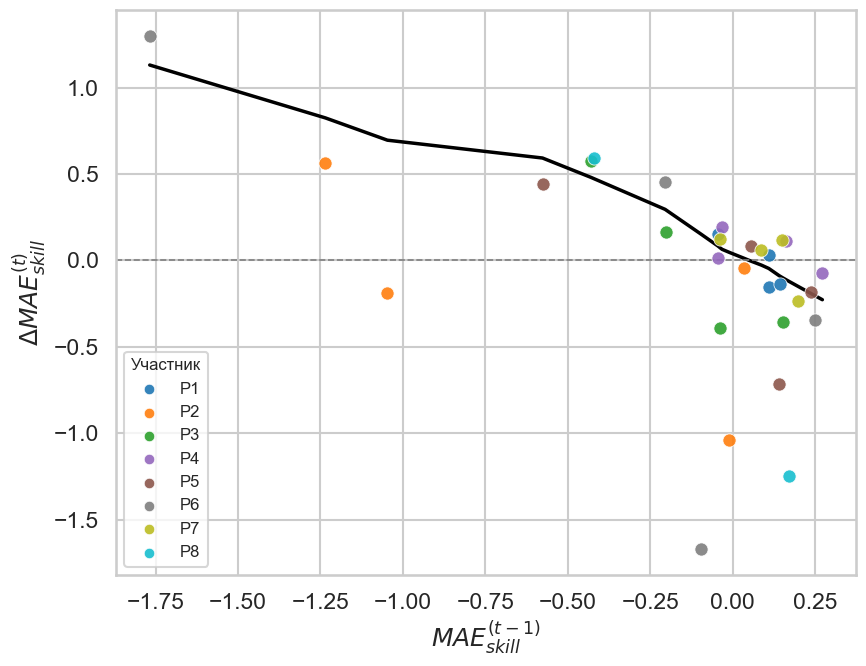

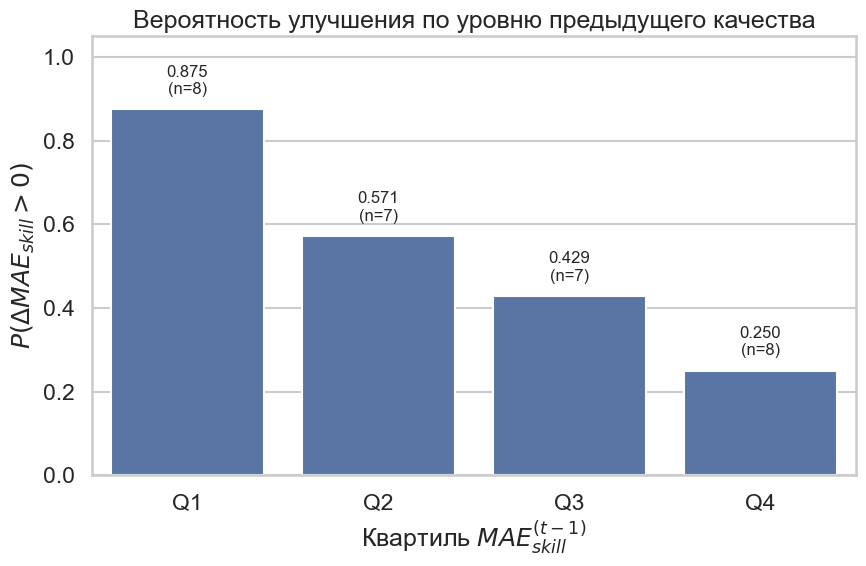

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid", context="talk")

# ---------- 0) Единая цветовая карта по username ----------
usernames = df["username"].unique()
cmap = plt.cm.get_cmap("tab10", len(usernames))
color_map = {name: cmap(i) for i, name in enumerate(usernames)}

# ---------- 1) Подготовка переходов ----------
df = df.sort_values(["user_id", "attempt_idx"]).copy()
df["prev_mae_skill"] = df.groupby("user_id")["mae_skill"].shift(1)

tr = df[(df["attempt_idx"] > 1)].dropna(subset=["prev_mae_skill", "delta_mae_skill"]).copy()
tr["improve"] = (tr["delta_mae_skill"] > 0).astype(int)

r_s, p_s = stats.spearmanr(tr["prev_mae_skill"], tr["delta_mae_skill"])

# ---------- 2) Рисунок A: scatter + тренд ----------
plt.figure(figsize=(9, 7))

# Рисуем каждого пользователя отдельно — для единых цветов и легенды
for username in usernames:
    mask = tr["username"] == username
    if mask.sum() == 0:
        continue
    plt.scatter(
        tr.loc[mask, "prev_mae_skill"],
        tr.loc[mask, "delta_mae_skill"],
        color=color_map[username],
        label=username,
        s=90,
        alpha=0.9,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

# Линия тренда
try:
    sns.regplot(
        data=tr,
        x="prev_mae_skill",
        y="delta_mae_skill",
        scatter=False,
        lowess=True,
        color="black",
        line_kws={"lw": 2.5}
    )
except Exception:
    sns.regplot(
        data=tr,
        x="prev_mae_skill",
        y="delta_mae_skill",
        scatter=False,
        color="black",
        line_kws={"lw": 2.5}
    )

plt.axhline(0, color="gray", lw=1.2, ls="--")
plt.xlabel(r"$MAE_{skill}^{(t-1)}$")
plt.ylabel(r"$\Delta MAE_{skill}^{(t)}$")

# --- Легенда ---
plt.legend(
    #bbox_to_anchor=(1.05, 1),
    loc="lower left",
    fontsize=12,
    title="Участник",
    title_fontsize=12,
    markerscale=0.8
)

plt.tight_layout()
plt.savefig("fig_headroom_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------- 3) Рисунок B: доля улучшений по квартилям ----------
tr["q"] = pd.qcut(tr["prev_mae_skill"], 4, labels=["Q1", "Q2", "Q3", "Q4"])
rate = tr.groupby("q", observed=True)["improve"].agg(["mean", "count"]).reset_index()

plt.figure(figsize=(9, 6))
ax2 = sns.barplot(
    data=rate,
    x="q",
    y="mean",
    color="#4C72B0"
)

for i, row in rate.iterrows():
    ax2.text(i, row["mean"] + 0.03, f"{row['mean']:.3f}\n(n={int(row['count'])})",
             ha="center", va="bottom", fontsize=12)

plt.ylim(0, 1.05)
plt.title("Вероятность улучшения по уровню предыдущего качества")
plt.xlabel(r"Квартиль $MAE_{skill}^{(t-1)}$")
plt.ylabel(r"$P(\Delta MAE_{skill} > 0)$")

plt.tight_layout()
plt.savefig("fig_headroom_quartiles.png", dpi=300)
plt.show()

In [81]:
# Создаём color_map (если ещё не создан)
usernames = df["username"].unique()
cmap = plt.cm.get_cmap("tab10", len(usernames))
color_map = {name: cmap(i) for i, name in enumerate(usernames)}

# --- Вариант 1: RGBA кортежи ---
for name, rgba in color_map.items():
    print(f"{name}: RGBA = {rgba}")

# --- Вариант 2: HEX ---
from matplotlib.colors import to_hex
for name, rgba in color_map.items():
    print(f"{name}: {to_hex(rgba)}")

# --- Вариант 3: RGB 0-255 ---
for name, rgba in color_map.items():
    r, g, b, a = rgba
    print(f"{name}: rgb({int(r*255)}, {int(g*255)}, {int(b*255)})")

# --- Вариант 4: Красивая таблица ---
color_table = pd.DataFrame([
    {
        "username": name,
        "hex": to_hex(rgba),
        "R": int(rgba[0]*255),
        "G": int(rgba[1]*255),
        "B": int(rgba[2]*255),
    }
    for name, rgba in color_map.items()
])
print(color_table.to_string(index=False))

P1: RGBA = (0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0)
P2: RGBA = (1.0, 0.4980392156862745, 0.054901960784313725, 1.0)
P3: RGBA = (0.17254901960784313, 0.6274509803921569, 0.17254901960784313, 1.0)
P4: RGBA = (0.5803921568627451, 0.403921568627451, 0.7411764705882353, 1.0)
P5: RGBA = (0.5490196078431373, 0.33725490196078434, 0.29411764705882354, 1.0)
P6: RGBA = (0.4980392156862745, 0.4980392156862745, 0.4980392156862745, 1.0)
P7: RGBA = (0.7372549019607844, 0.7411764705882353, 0.13333333333333333, 1.0)
P8: RGBA = (0.09019607843137255, 0.7450980392156863, 0.8117647058823529, 1.0)
P1: #1f77b4
P2: #ff7f0e
P3: #2ca02c
P4: #9467bd
P5: #8c564b
P6: #7f7f7f
P7: #bcbd22
P8: #17becf
P1: rgb(31, 119, 180)
P2: rgb(255, 127, 14)
P3: rgb(44, 160, 44)
P4: rgb(148, 103, 189)
P5: rgb(140, 86, 75)
P6: rgb(127, 127, 127)
P7: rgb(188, 189, 34)
P8: rgb(23, 190, 207)
username     hex   R   G   B
      P1 #1f77b4  31 119 180
      P2 #ff7f0e 255 127  14
      P3 #2ca02c  44 160  44
   